# Power Spectrum Analysis: UV vs IR Tilting

This notebook visualizes different power law behaviors in Fourier space:
- **UV tilted**: $|k|^{-\alpha}$ with $\alpha < 2$ (power concentrated at high frequencies)
- **IR tilted**: $|k|^{-\alpha}$ with $\alpha > 2$ (power concentrated at low frequencies)
- **White noise**: Constant power across all frequencies
- **$\delta'(\vec{x})$**: Derivative of delta function ($\alpha = -1$, giving $|k|^{1}$)


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12


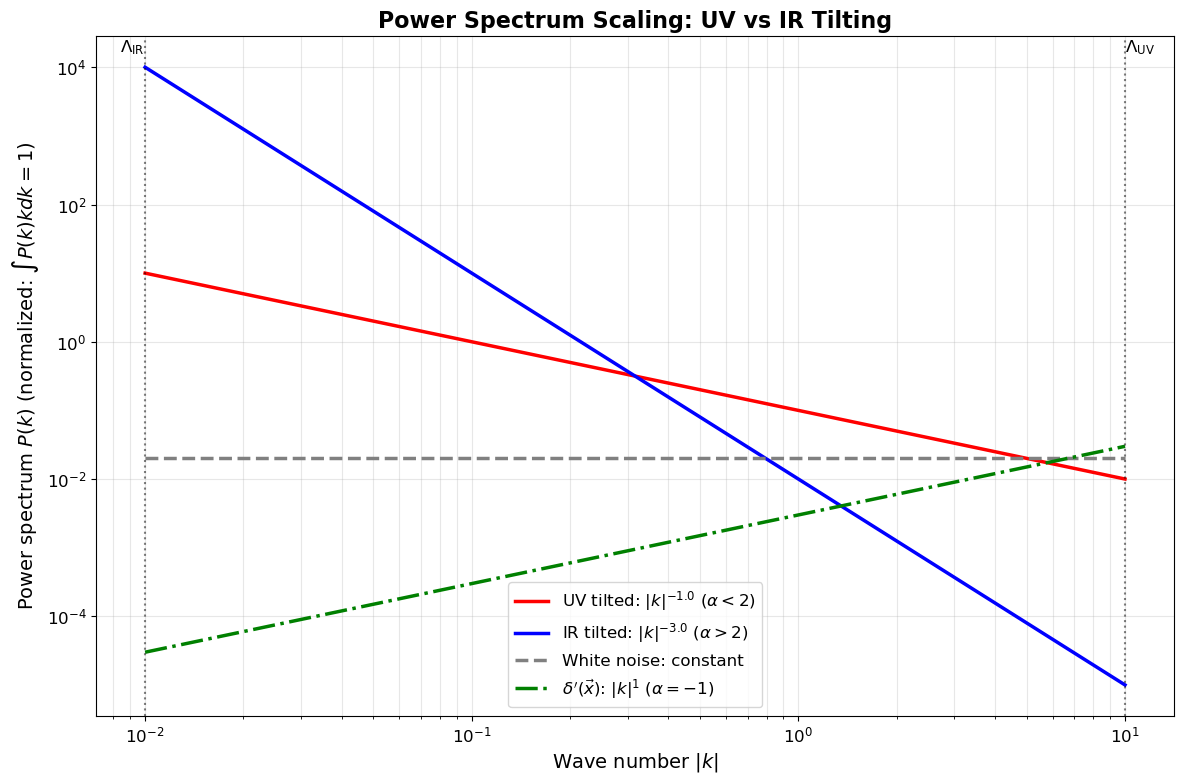

In [15]:
# Define frequency range
Lambda_IR = 1e-2  # Infrared cutoff
Lambda_UV = 1e1   # Ultraviolet cutoff

# Create k values on log scale
k = np.logspace(np.log10(Lambda_IR), np.log10(Lambda_UV), 1000)

# Define different alpha values
alpha_uv = 1.0      # UV tilted (α < 2)
alpha_ir = 3.0      # IR tilted (α > 2)
alpha_delta_prime = -1.0  # Derivative of delta function

def normalize_power_spectrum(k_array, alpha, k_min, k_max):
    """
    Normalize f(k) = A * k^(-alpha) so that ∫ f(k) k dk = 1
    
    For power law k^(-alpha), the integral is ∫ A k^(-alpha) k dk = A ∫ k^(1-alpha) dk
    
    For alpha ≠ 2:
        A = (2 - alpha) / (k_max^(2-alpha) - k_min^(2-alpha))
    
    For alpha = 2:
        A = 1 / ln(k_max/k_min)
    """
    beta = 1 - alpha  # Exponent in the integral
    
    if np.abs(alpha - 2.0) < 1e-10:  # Special case: alpha = 2
        A = 1.0 / np.log(k_max / k_min)
    else:
        A = (2 - alpha) / (k_max**(2 - alpha) - k_min**(2 - alpha))
    
    return A * k_array**(-alpha)

# Compute normalized power spectra using |k|^(-alpha)
# Each satisfies ∫ f(k) k dk = 1 from Lambda_IR to Lambda_UV
P_uv = normalize_power_spectrum(k, alpha_uv, Lambda_IR, Lambda_UV)
P_ir = normalize_power_spectrum(k, alpha_ir, Lambda_IR, Lambda_UV)

# For white noise (constant), normalize so ∫ A k dk = 1
# This gives A * (k_max^2 - k_min^2)/2 = 1
A_white = 2.0 / (Lambda_UV**2 - Lambda_IR**2)
P_white = np.ones_like(k) * A_white

P_delta_prime = normalize_power_spectrum(k, alpha_delta_prime, Lambda_IR, Lambda_UV)

# Create log-log plot
plt.figure(figsize=(12, 8))

# Plot different power laws
plt.loglog(k, P_uv, linewidth=2.5, label=f'UV tilted: $|k|^{{-{alpha_uv}}}$ ($\\alpha < 2$)', color='red')
plt.loglog(k, P_ir, linewidth=2.5, label=f'IR tilted: $|k|^{{-{alpha_ir}}}$ ($\\alpha > 2$)', color='blue')
plt.loglog(k, P_white, linewidth=2.5, linestyle='--', label='White noise: constant', color='gray')
plt.loglog(k, P_delta_prime, linewidth=2.5, linestyle='-.', label=r"$\delta'(\vec{x})$: $|k|^{1}$ ($\alpha = -1$)", color='green')

# Add vertical lines for cutoffs
plt.axvline(Lambda_IR, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
plt.axvline(Lambda_UV, color='black', linestyle=':', alpha=0.5, linewidth=1.5)

# Labels and formatting
plt.xlabel('Wave number $|k|$', fontsize=14)
plt.ylabel('Power spectrum $P(k)$ (normalized: $\\int P(k) k dk = 1$)', fontsize=14)
plt.title('Power Spectrum Scaling: UV vs IR Tilting', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, which='both', alpha=0.3)

# Add annotations for cutoffs
plt.text(Lambda_IR, plt.ylim()[1]*0.5, r'$\Lambda_{\mathrm{IR}}$', 
         fontsize=12, ha='right', va='bottom', rotation=0)
plt.text(Lambda_UV, plt.ylim()[1]*0.5, r'$\Lambda_{\mathrm{UV}}$', 
         fontsize=12, ha='left', va='bottom', rotation=0)

plt.tight_layout()
plt.show()


## Additional Power Law Examples

Let's visualize a range of $\alpha$ values to see the transition from IR to UV tilting:


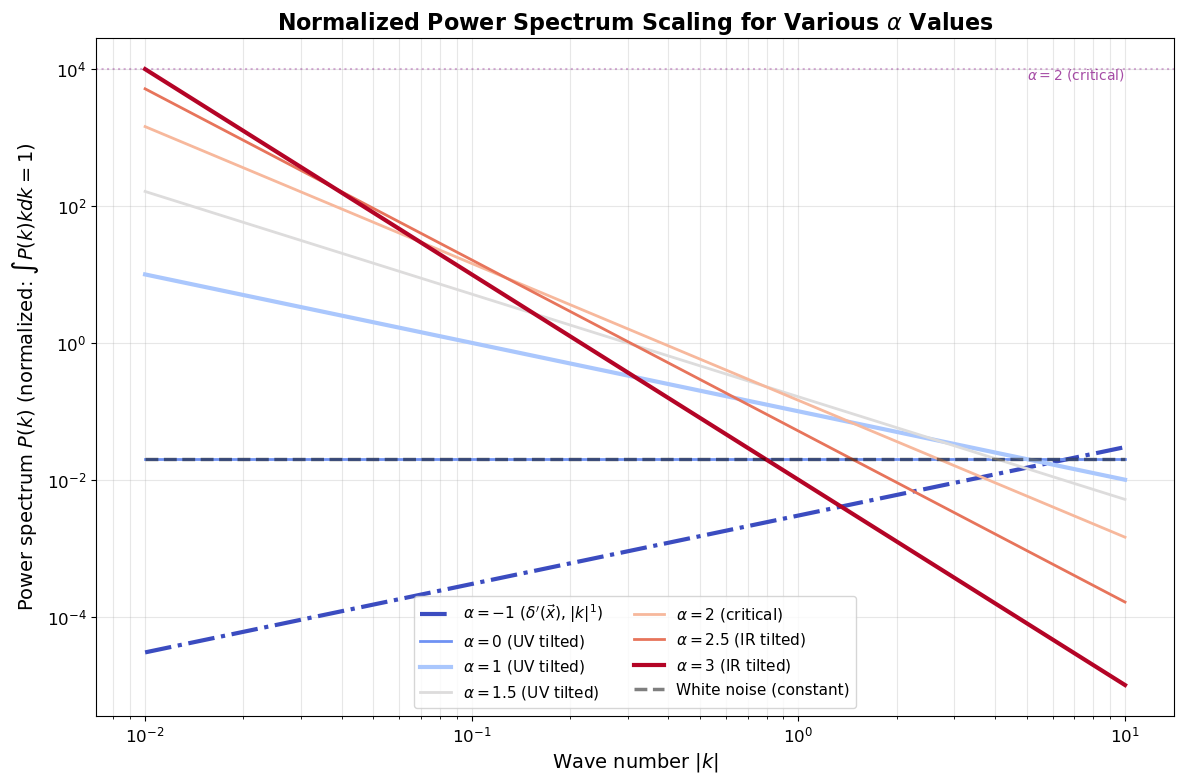

In [16]:
# Create a comprehensive plot with multiple alpha values
plt.figure(figsize=(12, 8))

# Range of alpha values
alphas = [-1, 0, 1, 1.5, 2, 2.5, 3]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(alphas)))

for alpha, color in zip(alphas, colors):
    # Use normalized power spectrum
    P_k = normalize_power_spectrum(k, alpha, Lambda_IR, Lambda_UV)
    
    # Determine label
    if alpha == -1:
        label = r"$\alpha = -1$ ($\delta'(\vec{x})$, $|k|^{1}$)"
    elif alpha > 2:
        label = f'$\\alpha = {alpha}$ (IR tilted)'
    elif alpha < 2:
        label = f'$\\alpha = {alpha}$ (UV tilted)'
    else:
        label = f'$\\alpha = {alpha}$ (critical)'
    
    linestyle = '-' if alpha != -1 else '-.'
    linewidth = 3 if alpha in [-1, 1, 3] else 2
    
    plt.loglog(k, P_k, linewidth=linewidth, linestyle=linestyle, label=label, color=color)

# Add white noise reference (also normalized)
P_white_plot = np.ones_like(k) * A_white
plt.loglog(k, P_white_plot, linewidth=2.5, linestyle='--', 
           label='White noise (constant)', color='black', alpha=0.5)

# Formatting
plt.xlabel('Wave number $|k|$', fontsize=14)
plt.ylabel('Power spectrum $P(k)$ (normalized: $\\int P(k) k dk = 1$)', fontsize=14)
plt.title('Normalized Power Spectrum Scaling for Various $\\alpha$ Values', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='best', ncol=2)
plt.grid(True, which='both', alpha=0.3)

# Mark the critical line alpha = 2
plt.axhline(Lambda_IR**(-2), color='purple', linestyle=':', alpha=0.3, linewidth=1.5)
plt.text(Lambda_UV*0.5, Lambda_IR**(-2) * 0.7, '$\\alpha = 2$ (critical)', 
         fontsize=10, color='purple', alpha=0.7)

plt.tight_layout()
plt.show()


## Interpretation

### Normalization

All power spectra are normalized so that $\int_{\Lambda_{\mathrm{IR}}}^{\Lambda_{\mathrm{UV}}} P(k) \, k \, dk = 1$.

For an unnormalized power law $f(k) = |k|^{-\alpha}$, the integral is:

$$\int_{\Lambda_{\mathrm{IR}}}^{\Lambda_{\mathrm{UV}}} |k|^{-\alpha} \, k \, dk = \int_{\Lambda_{\mathrm{IR}}}^{\Lambda_{\mathrm{UV}}} k^{1-\alpha} \, dk = \frac{1}{2-\alpha}\left(\Lambda_{\mathrm{UV}}^{2-\alpha} - \Lambda_{\mathrm{IR}}^{2-\alpha}\right)$$

To normalize, we divide by this integral:

$$P(k) = \frac{|k|^{-\alpha}}{\frac{1}{2-\alpha}\left(\Lambda_{\mathrm{UV}}^{2-\alpha} - \Lambda_{\mathrm{IR}}^{2-\alpha}\right)} = \frac{2-\alpha}{\Lambda_{\mathrm{UV}}^{2-\alpha} - \Lambda_{\mathrm{IR}}^{2-\alpha}} \, |k|^{-\alpha}$$

Special case: When $\alpha = 2$, the integral is $\ln(\Lambda_{\mathrm{UV}}/\Lambda_{\mathrm{IR}})$ and $A = 1/\ln(\Lambda_{\mathrm{UV}}/\Lambda_{\mathrm{IR}})$.

### Power Law Behavior with $P(k) \propto |k|^{-\alpha}$:

1. **UV Tilted** ($\alpha < 2$): 
   - Power decreases slowly with $|k|$ (or increases if $\alpha < 0$)
   - More power at high frequencies (small scales)
   - Signal is "rough" or has fine structure

2. **IR Tilted** ($\alpha > 2$):
   - Power decreases rapidly with $|k|$
   - More power at low frequencies (large scales)
   - Signal is "smooth" or has large-scale structure

3. **White Noise** (constant):
   - Equal power at all frequencies
   - No preferred scale

4. **$\delta'(\vec{x})$** ($\alpha = -1$):
   - Derivative of delta function
   - Power increases linearly as $|k|^{1}$
   - Related to spatial gradients
   - Highly UV-tilted

### Relevance to Diffusion Models:

In the context of score-based diffusion models, the power spectrum of the score function $\nabla_x \log p_t(x)$ reveals:
- **High-frequency content** (UV): Captures fine details and edges
- **Low-frequency content** (IR): Captures global structure and low-frequency modes
- The balance between UV and IR components affects generation quality
- The critical value $\alpha = 2$ represents a transition point in the scaling behavior

## Verification of Normalization

Let's verify that the integrals $\int P(k) \, k \, dk = 1$ for all our power spectra:

In [17]:
# Verify normalization by numerical integration
# Compute the integrands: P(k) * k
integrand_uv = P_uv * k
integrand_ir = P_ir * k
integrand_white = P_white * k
integrand_delta_prime = P_delta_prime * k

# Integrate using trapezoidal rule
integral_uv = np.trapz(integrand_uv, k)
integral_ir = np.trapz(integrand_ir, k)
integral_white = np.trapz(integrand_white, k)
integral_delta_prime = np.trapz(integrand_delta_prime, k)

# Display results
print("Verification of normalization ∫ P(k) k dk = 1:")
print("=" * 50)
print(f"UV tilted (α = {alpha_uv}):       {integral_uv:.6f}")
print(f"IR tilted (α = {alpha_ir}):       {integral_ir:.6f}")
print(f"White noise:                        {integral_white:.6f}")
print(f"δ'(x⃗) (α = {alpha_delta_prime}):  {integral_delta_prime:.6f}")
print("=" * 50)
print("\nAll integrals should be approximately 1.0")

Verification of normalization ∫ P(k) k dk = 1:
UV tilted (α = 1.0):       1.000000
IR tilted (α = 3.0):       1.000024
White noise:                        1.000000
δ'(x⃗) (α = -1.0):  1.000008

All integrals should be approximately 1.0


C:\Users\henhen724\AppData\Local\Temp\ipykernel_502012\2687088562.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_uv = np.trapz(integrand_uv, k)
C:\Users\henhen724\AppData\Local\Temp\ipykernel_502012\2687088562.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_ir = np.trapz(integrand_ir, k)
C:\Users\henhen724\AppData\Local\Temp\ipykernel_502012\2687088562.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_white = np.trapz(integrand_white, k)
C:\Users\henhen724\AppData\Local\Temp\ipykernel_502012\2687088562.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_delta_prime = np.trapz

## Animation: Adding Noise to Image Data

Let's visualize how the power spectrum evolves when we add noise to image data. Starting with a slightly UV-tilted image spectrum and progressively adding white noise:

$$P(k, \bar{\alpha}) = (1 - \bar{\alpha}) f_{\mathrm{img}}(k) + \bar{\alpha} f_{\mathrm{noise}}(k)$$

where $\bar{\alpha} \in [0, 1]$ represents the noise level.

Creating animation... This may take a moment.
Animation saved to: results/power_spectrum_noise_evolution.gif


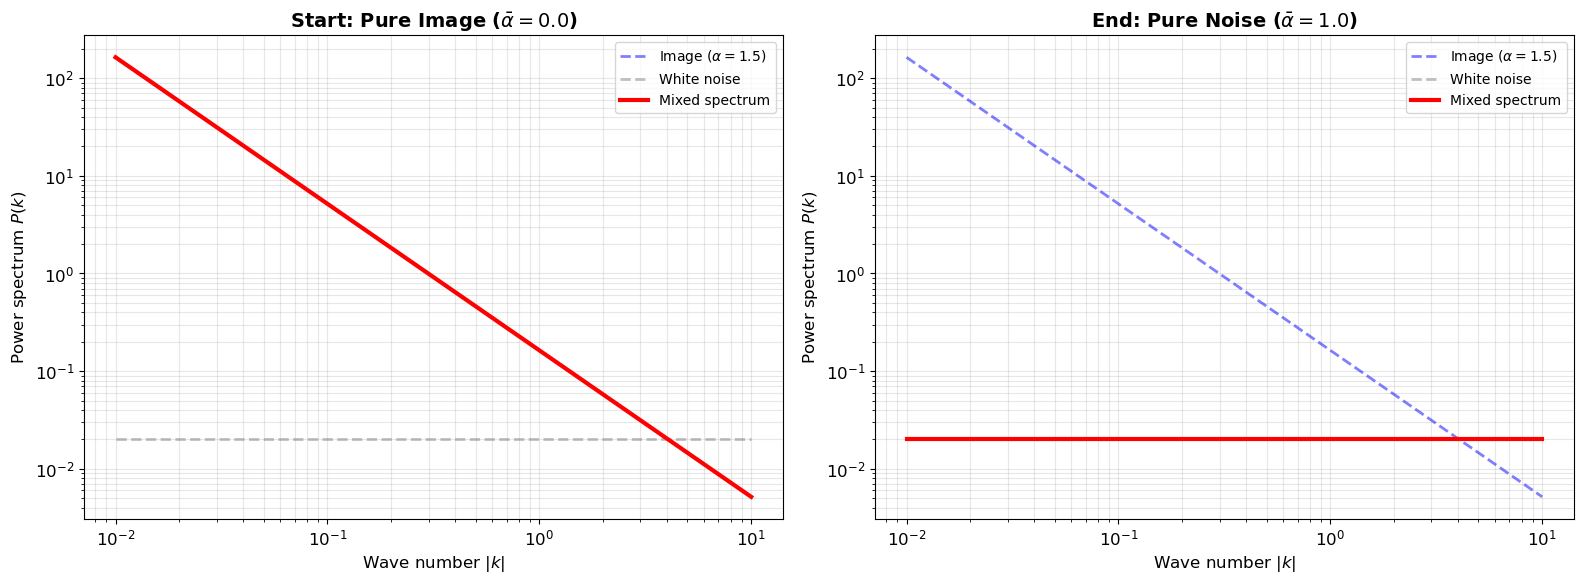

In [18]:
from matplotlib.animation import FuncAnimation, PillowWriter
import os

# Create results directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Define the image power spectrum (slightly UV tilted)
alpha_img = 1.5  # Slightly UV tilted (between white noise at α=0 and critical at α=2)
f_img = normalize_power_spectrum(k, alpha_img, Lambda_IR, Lambda_UV)

# Define noise power spectrum (white noise)
f_noise = np.ones_like(k) * A_white

# Create figure for animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Alpha bar values for the animation
alpha_bar_values = np.linspace(0, 1, 50)

def update(frame):
    alpha_bar = alpha_bar_values[frame]
    
    # Mix the spectra
    P_mixed = (1 - alpha_bar) * f_img + alpha_bar * f_noise
    
    # Clear axes
    ax1.clear()
    ax2.clear()
    
    # Left plot: Log-log plot of power spectrum
    ax1.loglog(k, f_img, 'b--', linewidth=2, label=f'Image ($\\alpha = {alpha_img}$, UV tilted)', alpha=0.5)
    ax1.loglog(k, f_noise, 'gray', linestyle='--', linewidth=2, label='White noise', alpha=0.5)
    ax1.loglog(k, P_mixed, 'red', linewidth=3, label=f'Mixed spectrum')
    ax1.axvline(Lambda_IR, color='black', linestyle=':', alpha=0.3)
    ax1.axvline(Lambda_UV, color='black', linestyle=':', alpha=0.3)
    ax1.set_xlabel('Wave number $|k|$', fontsize=12)
    ax1.set_ylabel('Power spectrum $P(k)$', fontsize=12)
    ax1.set_title(f'Power Spectrum Evolution: $\\bar{{\\alpha}} = {alpha_bar:.3f}$', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, which='both', alpha=0.3)
    
    # Right plot: Linear-linear plot to show the mixing more clearly
    ax2.plot(k, f_img, 'b--', linewidth=2, label=f'Image ($\\alpha = {alpha_img}$)', alpha=0.5)
    ax2.plot(k, f_noise, 'gray', linestyle='--', linewidth=2, label='White noise', alpha=0.5)
    ax2.plot(k, P_mixed, 'red', linewidth=3, label=f'Mixed spectrum')
    ax2.set_xlabel('Wave number $|k|$', fontsize=12)
    ax2.set_ylabel('Power spectrum $P(k)$', fontsize=12)
    ax2.set_title(f'Linear Scale View', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([Lambda_IR, Lambda_UV])
    
    # Add progress bar
    fig.text(0.5, 0.02, f'Noise level: {alpha_bar:.1%}', 
             ha='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    return ax1, ax2

# Create animation
anim = FuncAnimation(fig, update, frames=len(alpha_bar_values), interval=100, blit=False)

# Save as GIF
output_file = 'results/power_spectrum_noise_evolution.gif'
print(f"Creating animation... This may take a moment.")
anim.save(output_file, writer=PillowWriter(fps=10))
print(f"Animation saved to: {output_file}")

plt.close(fig)

# Display the first and last frames
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (alpha_bar, ax, title) in enumerate([(0, axes[0], 'Start: Pure Image'), 
                                                (1, axes[1], 'End: Pure Noise')]):
    P_mixed = (1 - alpha_bar) * f_img + alpha_bar * f_noise
    ax.loglog(k, f_img, 'b--', linewidth=2, label=f'Image ($\\alpha = {alpha_img}$)', alpha=0.5)
    ax.loglog(k, f_noise, 'gray', linestyle='--', linewidth=2, label='White noise', alpha=0.5)
    ax.loglog(k, P_mixed, 'red', linewidth=3, label='Mixed spectrum')
    ax.set_xlabel('Wave number $|k|$', fontsize=12)
    ax.set_ylabel('Power spectrum $P(k)$', fontsize=12)
    ax.set_title(f'{title} ($\\bar{{\\alpha}} = {alpha_bar:.1f}$)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison: Varying Noise Spectrum ($\alpha_{\mathrm{img}}$ vs $\alpha_{\mathrm{noise}}$)

Let's explore what happens when we add UV-tilted noise with different $\alpha$ values. We'll compare noise spectra where $\alpha_{\mathrm{noise}} < \alpha_{\mathrm{img}}$ (more UV power than image) and $\alpha_{\mathrm{noise}} > \alpha_{\mathrm{img}}$ (less UV power than image), while keeping everything in the UV-tilted regime ($\alpha < 2$):

In [20]:
# Define different UV-tilted noise alpha values
# Image has alpha = 1.5, we'll test noise with alpha ranging from less to more
noise_alphas = [0.5, 1.0, 1.3, 1.5, 1.7, 1.9]  # All UV-tilted (< 2)

noise_types = {}
for alpha_noise in noise_alphas:
    if alpha_noise < alpha_img:
        relation = f'More UV-tilted than image'
    elif alpha_noise > alpha_img:
        relation = f'Less UV-tilted than image'
    else:
        relation = f'Same as image'
    
    noise_types[f'α_noise = {alpha_noise}'] = (alpha_noise, 
                                                 normalize_power_spectrum(k, alpha_noise, Lambda_IR, Lambda_UV),
                                                 relation)

# Create animations for each noise type
for noise_name, (alpha_noise, f_noise_type, relation) in noise_types.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    def update(frame):
        alpha_bar = alpha_bar_values[frame]
        P_mixed = (1 - alpha_bar) * f_img + alpha_bar * f_noise_type
        
        ax1.clear()
        ax2.clear()
        
        # Log-log plot
        ax1.loglog(k, f_img, 'b--', linewidth=2, label=f'Image: $\\alpha_{{img}} = {alpha_img}$', alpha=0.5)
        ax1.loglog(k, f_noise_type, 'gray', linestyle='--', linewidth=2, 
                   label=f'Noise: $\\alpha_{{noise}} = {alpha_noise}$ ({relation})', alpha=0.5)
        ax1.loglog(k, P_mixed, 'red', linewidth=3, label='Mixed spectrum')
        ax1.set_xlabel('Wave number $|k|$', fontsize=12)
        ax1.set_ylabel('Power spectrum $P(k)$', fontsize=12)
        ax1.set_title(f'$\\alpha_{{img}}={alpha_img}$ vs $\\alpha_{{noise}}={alpha_noise}$: $\\bar{{\\alpha}} = {alpha_bar:.3f}$', 
                      fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, which='both', alpha=0.3)
        
        # Linear plot
        ax2.plot(k, f_img, 'b--', linewidth=2, label=f'Image: $\\alpha_{{img}} = {alpha_img}$', alpha=0.5)
        ax2.plot(k, f_noise_type, 'gray', linestyle='--', linewidth=2, 
                 label=f'Noise: $\\alpha_{{noise}} = {alpha_noise}$', alpha=0.5)
        ax2.plot(k, P_mixed, 'red', linewidth=3, label='Mixed spectrum')
        ax2.set_xlabel('Wave number $|k|$', fontsize=12)
        ax2.set_ylabel('Power spectrum $P(k)$', fontsize=12)
        ax2.set_title(f'Linear Scale View', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=10, loc='best')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim([Lambda_IR, Lambda_UV])
        
        fig.text(0.5, 0.02, f'Noise level: {alpha_bar:.1%}', 
                 ha='center', fontsize=14, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        return ax1, ax2
    
    anim = FuncAnimation(fig, update, frames=len(alpha_bar_values), interval=100, blit=False)
    
    # Save with descriptive filename
    alpha_str = str(alpha_noise).replace('.', 'p')
    output_file = f'results/power_spectrum_alpha_img_{str(alpha_img).replace(".", "p")}_vs_alpha_noise_{alpha_str}.gif'
    print(f"Creating animation for α_img={alpha_img} vs α_noise={alpha_noise}...")
    anim.save(output_file, writer=PillowWriter(fps=10))
    print(f"  Saved to: {output_file}")
    
    plt.close(fig)

print("\nAll animations created!")

Creating animation for α_img=1.5 vs α_noise=0.5...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_0p5.gif
Creating animation for α_img=1.5 vs α_noise=1.0...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_1p0.gif
Creating animation for α_img=1.5 vs α_noise=1.3...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_1p3.gif
Creating animation for α_img=1.5 vs α_noise=1.5...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_1p5.gif
Creating animation for α_img=1.5 vs α_noise=1.7...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_1p7.gif
Creating animation for α_img=1.5 vs α_noise=1.9...
  Saved to: results/power_spectrum_alpha_img_1p5_vs_alpha_noise_1p9.gif

All animations created!


## Interpretation of Noise Addition

The animations show how the power spectrum evolves during a noise addition process, similar to the forward diffusion process in diffusion models:

### Key Observations - Comparing UV-Tilted Spectra:

All animations start with the same image spectrum ($\alpha_{\mathrm{img}} = 1.5$, UV-tilted) and add different UV-tilted noise spectra:

1. **When $\alpha_{\mathrm{noise}} < \alpha_{\mathrm{img}}$ (e.g., 0.5, 1.0, 1.3)**:
   - Noise has MORE UV power (stronger high-frequency content) than the image
   - Mixed spectrum becomes more UV-tilted (steeper positive slope in log-log)
   - Final spectrum is dominated by high-frequency noise
   - Models: Adding sharp, high-frequency perturbations

2. **When $\alpha_{\mathrm{noise}} = \alpha_{\mathrm{img}}$ (1.5)**:
   - Noise and image have the same spectral shape
   - Mixed spectrum maintains the same power law throughout
   - Only overall amplitude changes
   - Standard case: spectral shape is preserved

3. **When $\alpha_{\mathrm{noise}} > \alpha_{\mathrm{img}}$ (e.g., 1.7, 1.9)**:
   - Noise has LESS UV power (weaker high-frequency content) than the image
   - Mixed spectrum becomes less UV-tilted (flatter in log-log)
   - Approaches the critical point ($\alpha = 2$) but stays UV-tilted
   - Models: Adding smoother, lower-frequency perturbations while maintaining UV character

### Connection to Diffusion Models:

In score-based diffusion models, the forward process typically adds Gaussian white noise:
$$x_t = \sqrt{1-\bar{\alpha}_t} \, x_0 + \sqrt{\bar{\alpha}_t} \, \epsilon$$

where $\epsilon \sim \mathcal{N}(0, I)$. In Fourier space, this corresponds to:
$$P_t(k) = (1-\bar{\alpha}_t) P_0(k) + \bar{\alpha}_t P_{\epsilon}(k)$$

Our animations visualize exactly this interpolation in spectral space!